In [1]:
%pip install seaborn

# Cleanup

First read in the data, see how it looks, decide if cleaning etc. needed



In [2]:
# Libaries
# Python version: 3.14

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Input
filename = "student_productivity_distraction_dataset_20000.csv"
df = pd.read_csv(filename)

In [4]:
# Student ID is irrelevant - should be removed / not considered
df = df.drop(columns=['student_id'])

# Encoding

In [5]:
# Use one-hot encoding for non-numerical columns
# The reason for one-hot encoding is so that nominal data eg. gender is not mistaken by the model for having an order
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

## Efficiency - A better metric to determine focus correlations

After analysing focus and productivity individually with other factors, we realized that focus was closely correlated with productivity alone. So it appeared as if productivity is the 'focus metric'. However, the dataset implies this is not the case. Moreover, certain correlations don't make sense, for example: study hours vs productivity. If a student studies more, they have more focus, however, studying itself shouldn't improve focus. Rather, a student that has more focus would study more. To elaborate, consider sleep. A student who sleeps more, should be more well-rested and therefore more focused. This makes sense. 

For our final analysis phase, we create a new metric based on productivity, and see if focus is correlated to it. In other words: focus vs productivity/factor. We determine whether the relation is inverse or not, based on the correlation heatmap.

In [6]:
# non-inverse relation
positive_factors = [
    'study_hours_per_day', 'sleep_hours', 'exercise_minutes',
    'breaks_per_day', 'coffee_intake_mg', 'attendance_percentage',
    'assignments_completed'
]

# inverse relation
negative_factors = [
    'phone_usage_hours', 'social_media_hours', 
    'youtube_hours', 'gaming_hours', 'stress_level'
]

for col in positive_factors:
    df[f'efficiency_{col}'] = df['productivity_score'] / (df[col] + 1e-9)

for col in negative_factors:
    df[f'efficiency_{col}'] = df['productivity_score'] * (df[col] + 1e-9)

efficiency_cols = [f'efficiency_{col}' for col in positive_factors + negative_factors]
df_efficiency = df[efficiency_cols + ['focus_score']].copy()
X = df_efficiency.drop(columns=['focus_score'])
y = df_efficiency['focus_score']



# Exploratory Analysis

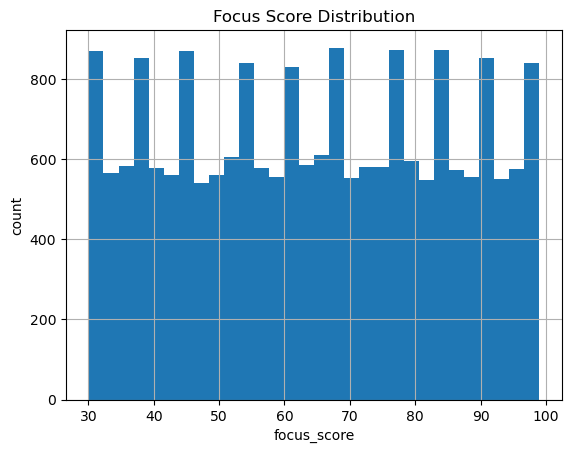

Skewness: -0.0021
count    20000.000000
mean        64.444350
std         20.176114
min         30.000000
25%         47.000000
50%         65.000000
75%         82.000000
max         99.000000
Name: focus_score, dtype: float64


In [7]:
# Check for skewness / if our target variable (focus scores) is not skewed towards any particular variable
df_efficiency['focus_score'].hist(bins=30)
plt.title('Focus Score Distribution')
plt.xlabel('focus_score')
plt.ylabel('count')
plt.show()

skew = df_efficiency['focus_score'].skew()
print(f"Skewness: {skew:.4f}")
print(df_efficiency['focus_score'].describe())

In [8]:
# Get an idea for which features correlate the most with focus
print(df_efficiency.corr(numeric_only=True)['focus_score'].sort_values(ascending=False))

focus_score                         1.000000
efficiency_sleep_hours              0.338142
efficiency_attendance_percentage    0.331698
efficiency_phone_usage_hours        0.237644
efficiency_stress_level             0.221808
efficiency_study_hours_per_day      0.202791
efficiency_youtube_hours            0.194219
efficiency_social_media_hours       0.193074
efficiency_gaming_hours             0.187613
efficiency_breaks_per_day           0.120022
efficiency_assignments_completed    0.029445
efficiency_exercise_minutes         0.020864
efficiency_coffee_intake_mg         0.000623
Name: focus_score, dtype: float64


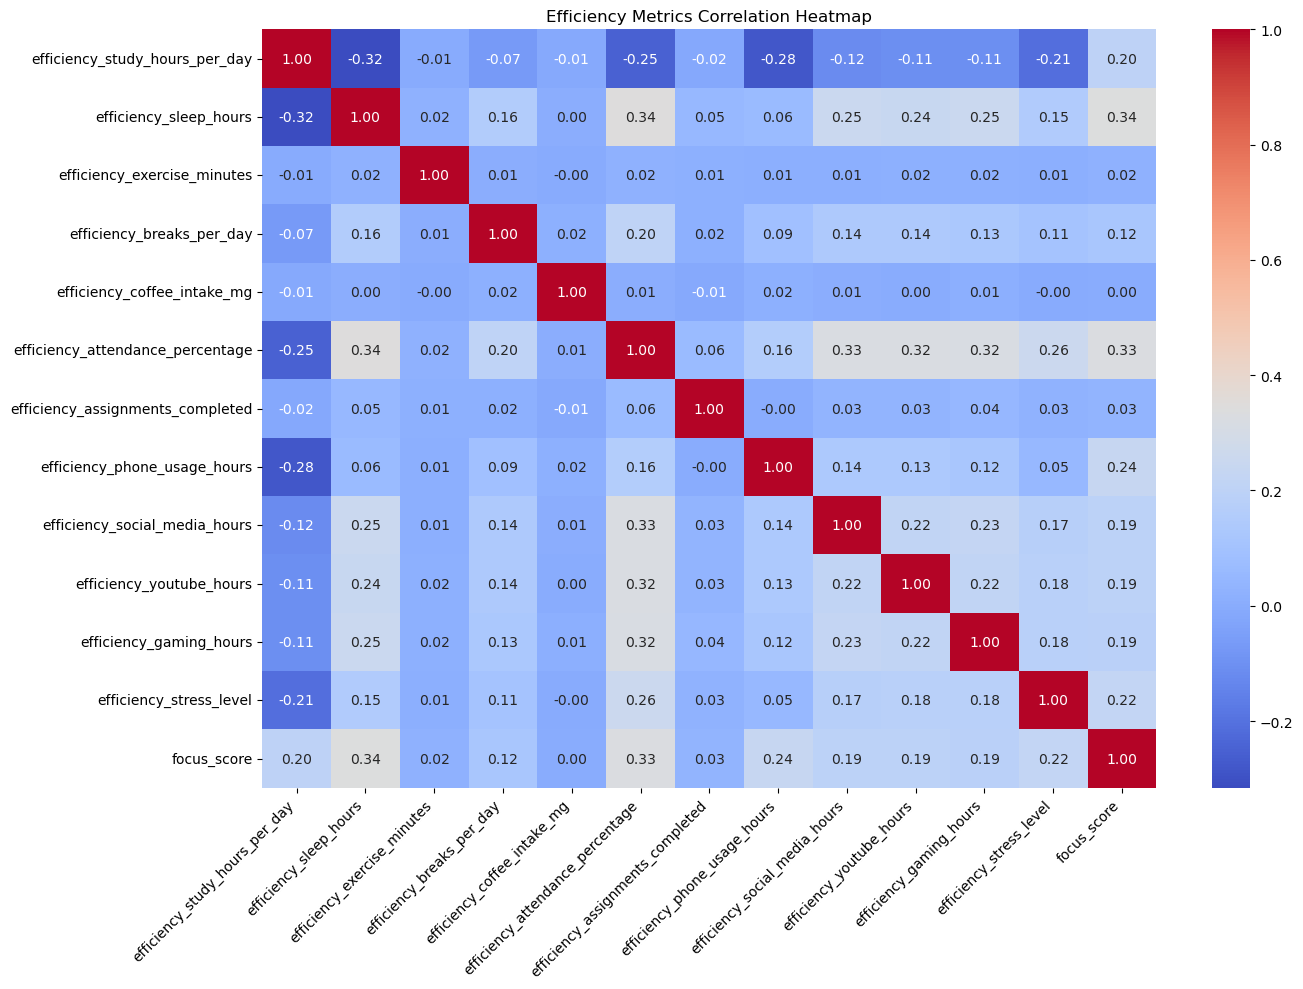

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_efficiency.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Efficiency Metrics Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

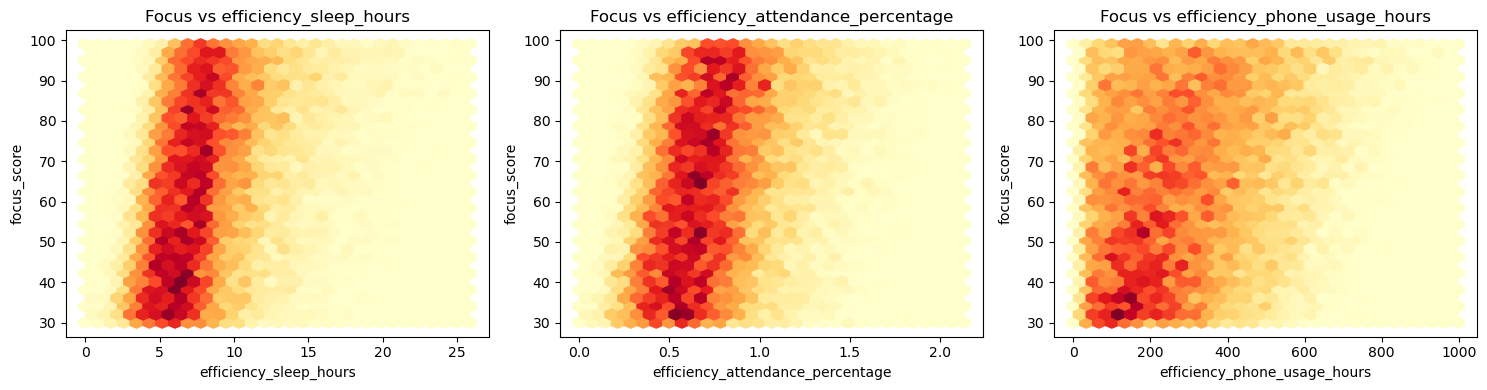

In [10]:
# Based on the heat map above, a hexbin for the most correlated features is a good idea

top3 = df_efficiency.corr()['focus_score'].drop('focus_score').abs().nlargest(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, top3):
    ax.hexbin(df_efficiency[col], df_efficiency['focus_score'], gridsize=30, cmap='YlOrRd')
    ax.set_xlabel(col); ax.set_ylabel('focus_score')
    ax.set_title(f'Focus vs {col}')
plt.tight_layout()
plt.show()

# Standardization

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X = df_efficiency.drop(columns=['focus_score'])
y = df_efficiency['focus_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.copy()
X_test = X_test.copy()

cols_to_scale = X_train.select_dtypes(include='number').columns
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression Training Complete")

Linear Regression Training Complete


Confusion Matrix

## Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Training Complete")

Random Forest Training Complete


Confusion Matrix

# Results Table

In [14]:
import pandas as pd
import numpy as np
results = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R²'],
    'Linear Regression': [
        round(mean_squared_error(y_test, y_pred_lr), 4),
        round(mean_absolute_error(y_test, y_pred_lr), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4),
        round(r2_score(y_test, y_pred_lr), 4)
    ],
    'Random Forest': [
        round(mean_squared_error(y_test, y_pred_rf), 4),
        round(mean_absolute_error(y_test, y_pred_rf), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4),
        round(r2_score(y_test, y_pred_rf), 4)
    ]
})
print(results.to_string(index=False))

Metric  Linear Regression  Random Forest
   MSE           236.9296        59.1373
   MAE            12.6600         6.0050
  RMSE            15.3925         7.6901
    R²             0.4060         0.8517


Confusion Matrix

# Feature Importance Plot

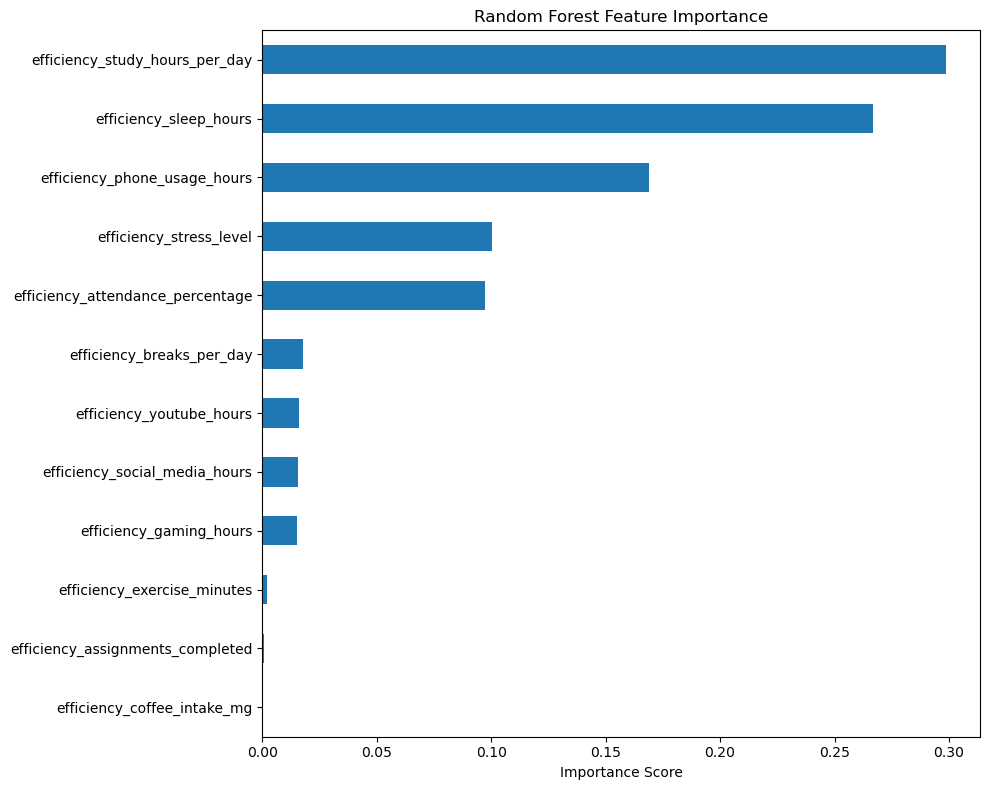

In [15]:

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Study hours should not exactly increase / affect focus. It should be the other way. There must be some hidden variable. 

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
components = pca.fit_transform(X_train)
print("Explained variance:", pca.explained_variance_ratio_)

# See which original features load heavily onto PC1
component_names = {
    'PC1': 'Engagement_Efficiency',    # attendance, sleep, limiting distractions
    'PC2': 'Distraction_Tendency',     # phone high, study low
    'PC3': 'Physical_Discipline'       # exercise + assignments, low caffeine
}

loadings = pd.DataFrame(pca.components_.T, 
                         index=X_train.columns, 
                         columns=list(component_names.values()))

print(loadings.sort_values('Engagement_Efficiency', ascending=False))

Explained variance: [0.21493535 0.09091056 0.08498734]
                                  Engagement_Efficiency  Distraction_Tendency  \
efficiency_attendance_percentage               0.449063             -0.098536   
efficiency_sleep_hours                         0.385841             -0.022804   
efficiency_social_media_hours                  0.349947             -0.158979   
efficiency_youtube_hours                       0.343313             -0.213791   
efficiency_gaming_hours                        0.342883             -0.209932   
efficiency_stress_level                        0.291103             -0.026824   
efficiency_breaks_per_day                      0.233158             -0.203614   
efficiency_phone_usage_hours                   0.224327              0.624161   
efficiency_assignments_completed               0.058558             -0.231341   
efficiency_exercise_minutes                    0.032736             -0.138461   
efficiency_coffee_intake_mg                    0.01549

PC1 accounted for the largest share of variance (21.5%) and was therefore interpreted as the most dominant behavioral pattern in the dataset. Based on its highest positive loadings, attendance efficiency (0.449) and sleep efficiency (0.386), along with its negative loading on study hour efficiency (0.312), we decided to label it as Engagement Efficiency. This component includes students who are productive / focused as a result of attending class and sleeping well, rather than studying more. The negative association with study hours suggests that study time may be a compensatory behavior. In other words, students with lower attendance or poorer sleep may need to invest more study hours to achieve comparable academic outcomes.

Random Forest feature importance identified sleep efficiency, phone usage efficiency, and stress level efficiency as the three highest-ranked predictors of productivity, consistent with prior literature linking excessive smartphone use to degraded sleep quality and elevated psychological stress. The proximity of attendance efficiency in importance ranking further corroborates findings that stress and anxiety are associated with academic absenteeism."

Visualization

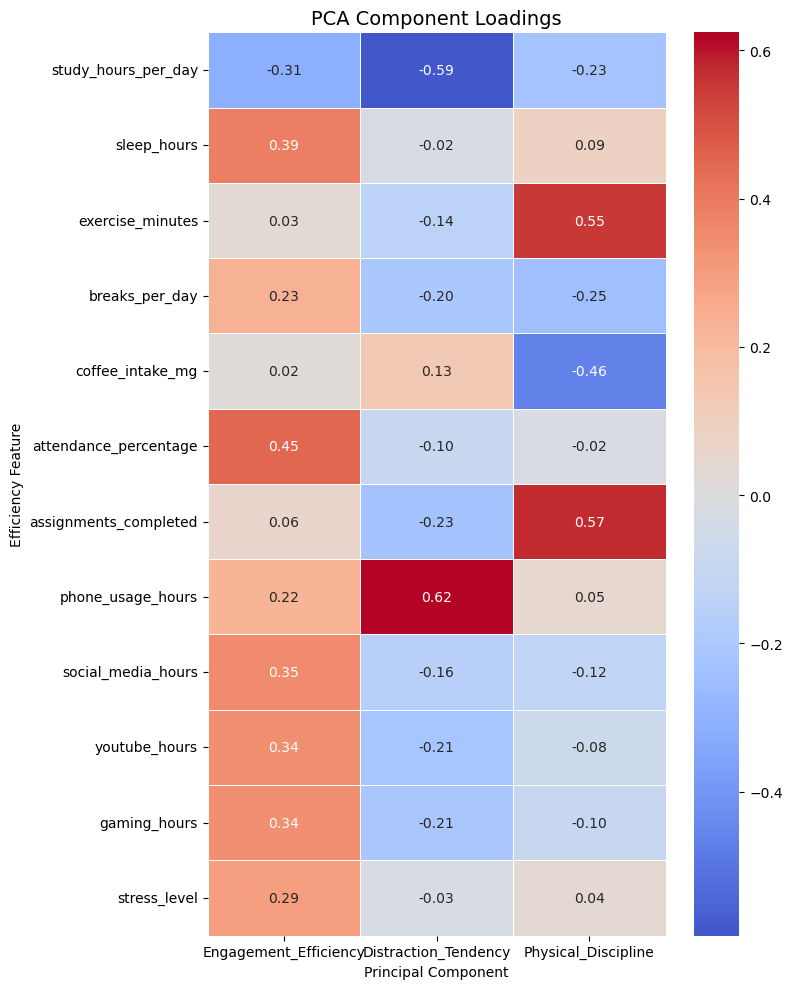

In [17]:
fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("PCA Component Loadings", fontsize=14)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Efficiency Feature")
ax.set_yticklabels(
    [label.get_text().replace("efficiency_", "") for label in ax.get_yticklabels()],
    rotation=0
)

plt.tight_layout()
plt.savefig("pcaLoadings.png", dpi=150, bbox_inches="tight")
plt.show()

# Evaluation

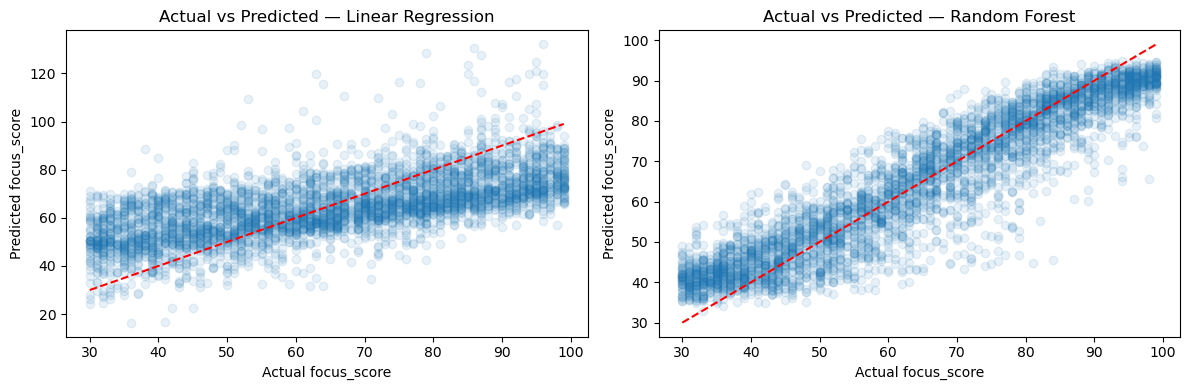

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]):
    ax.scatter(y_test, y_pred, alpha=0.1)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Actual focus_score')
    ax.set_ylabel('Predicted focus_score')
    ax.set_title(f'Actual vs Predicted — {name}')
plt.tight_layout()
plt.show()

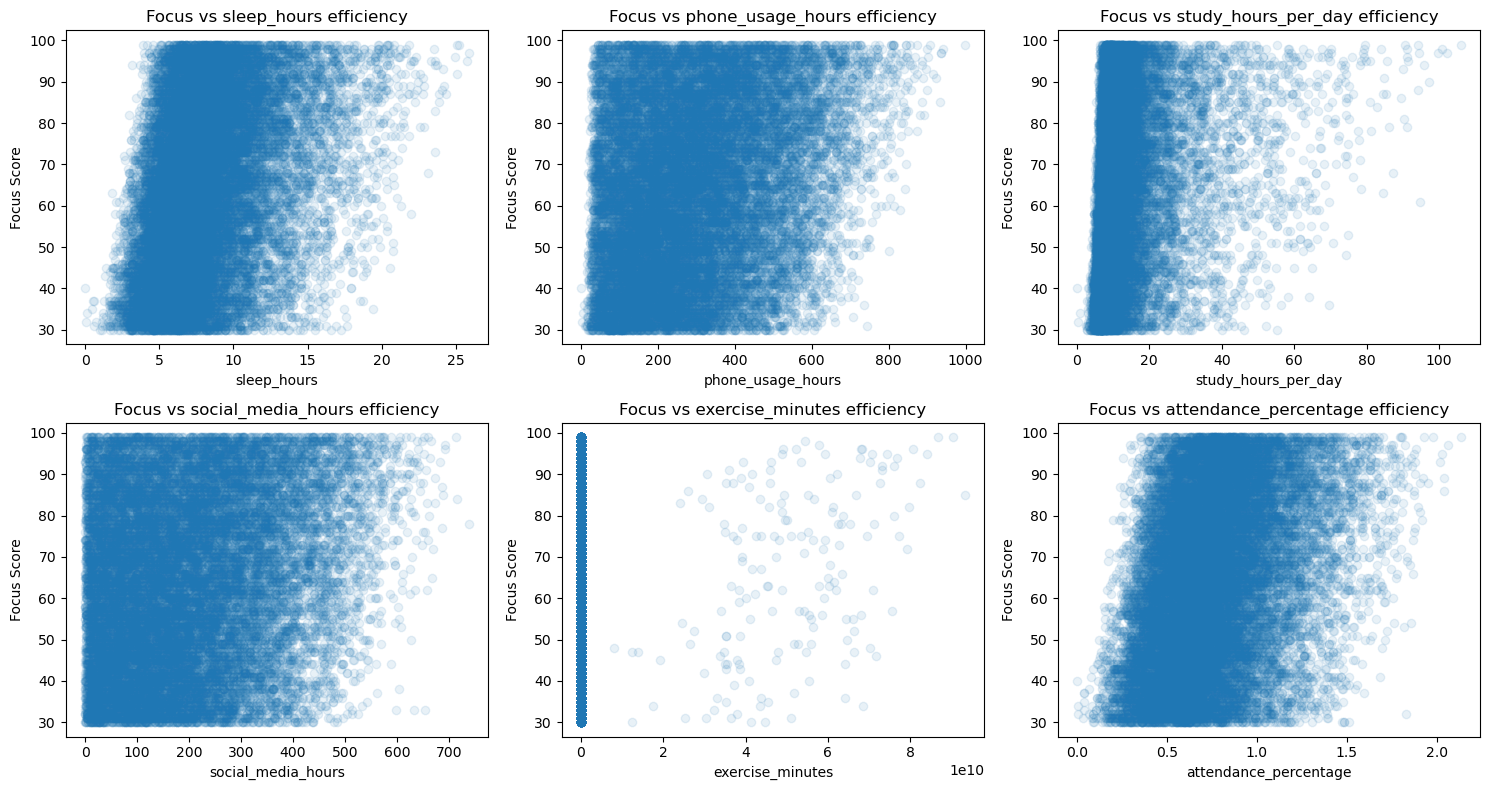

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Use efficiency cols — pick the ones most relevant to focus
plot_cols = [
    'efficiency_sleep_hours', 'efficiency_phone_usage_hours', 
    'efficiency_study_hours_per_day', 'efficiency_social_media_hours',
    'efficiency_exercise_minutes', 'efficiency_attendance_percentage'
]

for ax, col in zip(axes.flatten(), plot_cols):
    ax.scatter(df_efficiency[col], df_efficiency['focus_score'], alpha=0.1)
    ax.set_xlabel(col.replace('efficiency_', ''))
    ax.set_ylabel('Focus Score')
    ax.set_title(f'Focus vs {col.replace("efficiency_", "")} efficiency')

plt.tight_layout()
plt.show()

# Combination of features

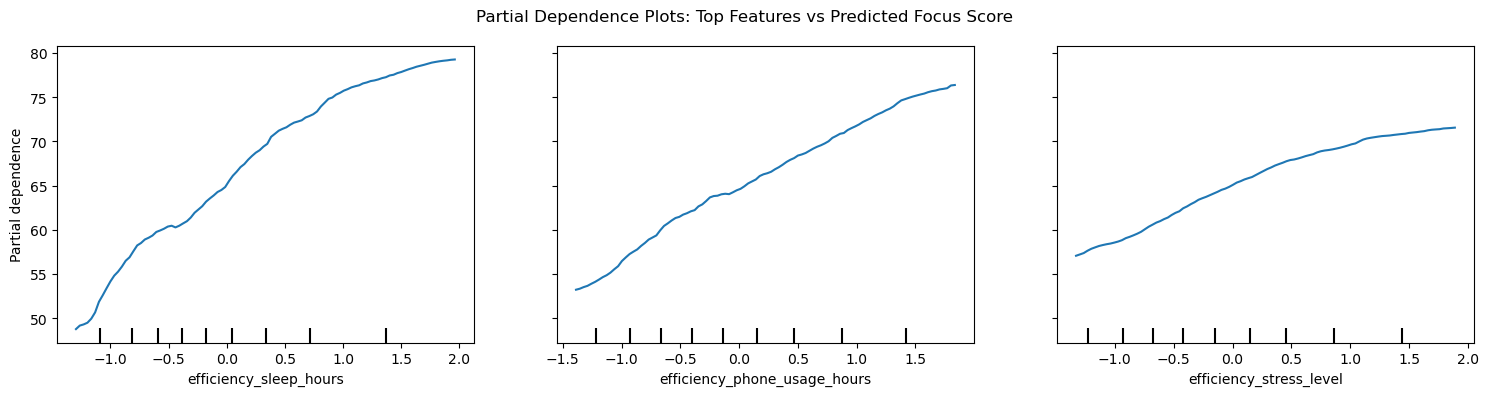

In [20]:
from sklearn.inspection import PartialDependenceDisplay

# We assume features are independant (even though this is never the case), to see the shape of the graph
fig, ax = plt.subplots(figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_train,
    features=['efficiency_sleep_hours', 'efficiency_phone_usage_hours', 
              'efficiency_stress_level'],
    ax=ax
)
plt.suptitle('Partial Dependence Plots: Top Features vs Predicted Focus Score')
plt.tight_layout()
plt.show()

Linear Regression Training Complete
Random Forest Training Complete


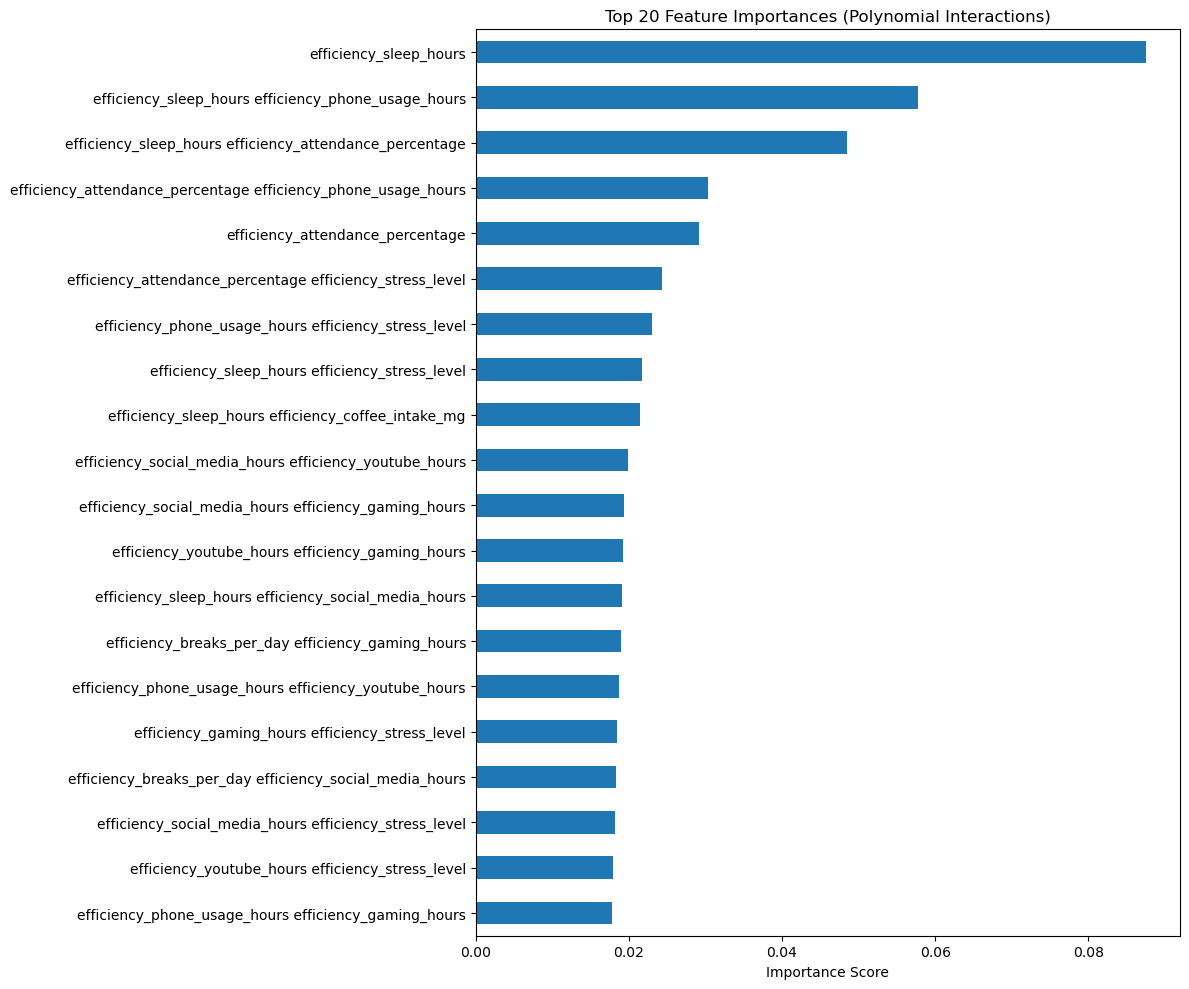

In [23]:
# Remove study hours as we established that it wasn't a factor of focus
from sklearn.preprocessing import PolynomialFeatures
X_train = X_train.drop(columns=['efficiency_study_hours_per_day'])
X_test = X_test.drop(columns=['efficiency_study_hours_per_day'])

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_feature_names = poly.get_feature_names_out(X_train.columns)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr = lr.predict(X_test_poly)
print("Linear Regression Training Complete")

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_poly, y_train)
y_pred_rf = rf.predict(X_test_poly)
print("Random Forest Training Complete")

importances = pd.Series(rf.feature_importances_, index=poly_feature_names)
importances.sort_values().tail(20).plot(kind='barh', figsize=(12, 10))
plt.title('Top 20 Feature Importances (Polynomial Interactions)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Connecting back to our findings from PCA, ignoring study hours as a stand-alone feature , our top 3 factors, considering combinations, are: sleep, (phone,sleep), (study,sleep)

Linear Regression Training Complete
Random Forest Training Complete


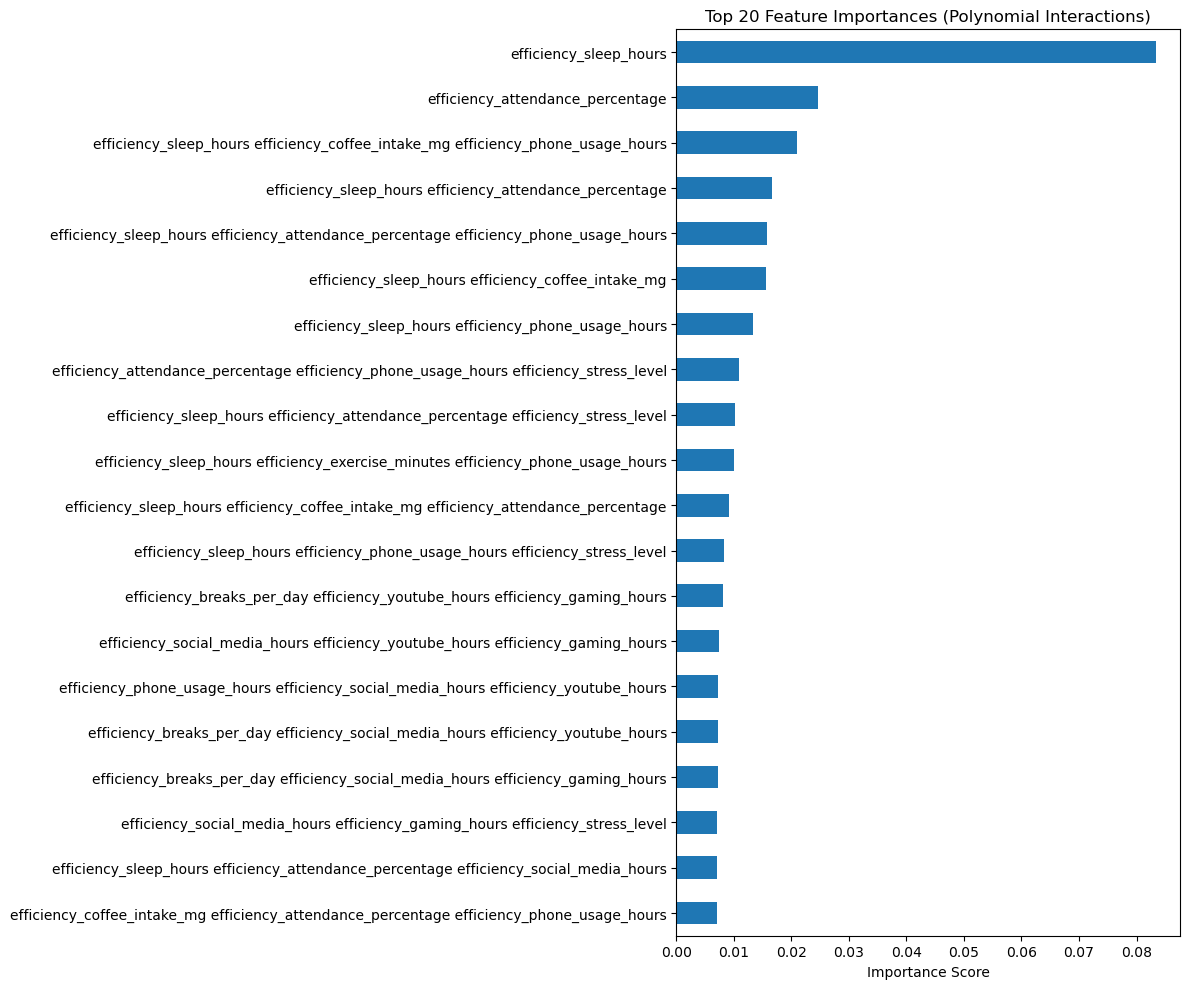

In [25]:
# Remove study hours as we established that it wasn't a factor of focus
from sklearn.preprocessing import PolynomialFeatures


from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_feature_names = poly.get_feature_names_out(X_train.columns)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr = lr.predict(X_test_poly)
print("Linear Regression Training Complete")

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_poly, y_train)
y_pred_rf = rf.predict(X_test_poly)
print("Random Forest Training Complete")

importances = pd.Series(rf.feature_importances_, index=poly_feature_names)
importances.sort_values().tail(20).plot(kind='barh', figsize=(12, 10))
plt.title('Top 20 Feature Importances (Polynomial Interactions)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Corr check

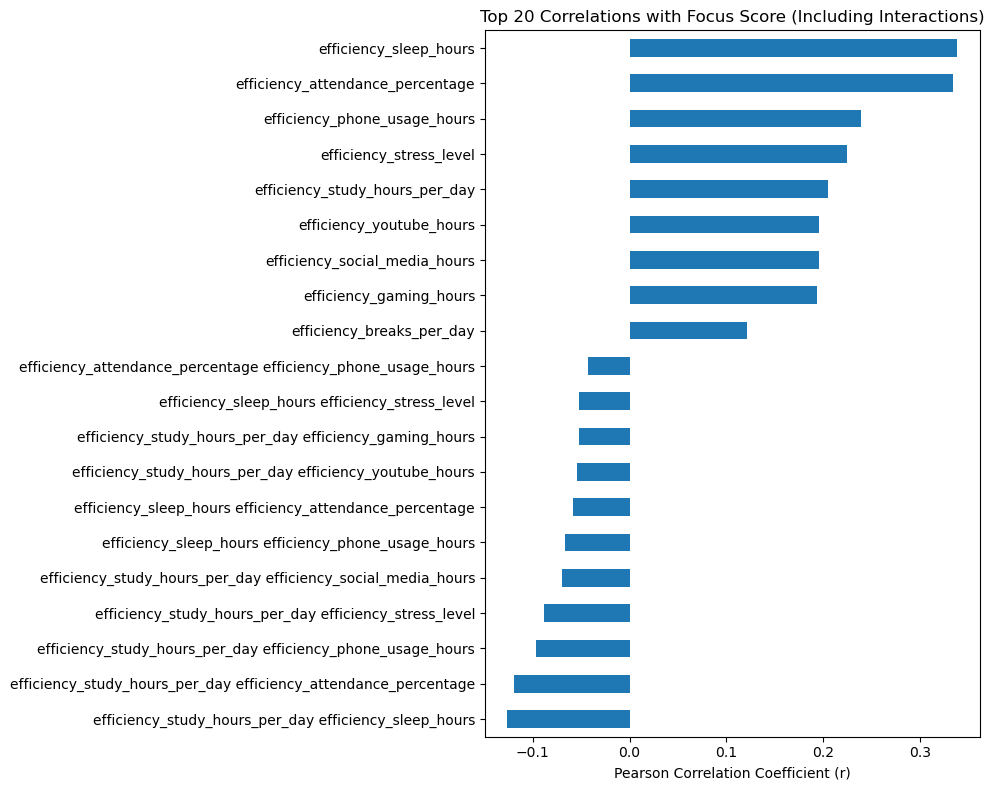

In [22]:
# 1. Convert the polynomial array back into a DataFrame using the new feature names
poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names)

# 2. Attach the target variable (resetting the index so the rows match up perfectly after the train_test_split)
poly_df['focus_score'] = y_train.reset_index(drop=True)

# 3. Calculate correlations of all features against focus_score, then drop focus_score itself so it doesn't correlate with itself (1.0)
correlations = poly_df.corr()['focus_score'].drop('focus_score')

# 4. Find the strongest correlations by looking at the absolute values (since a strong negative correlation is just as useful as a positive one)
top_correlations = correlations.abs().sort_values(ascending=False).head(20)

# 5. Plot the actual correlation values for the top 20
plt.figure(figsize=(10, 8))
correlations[top_correlations.index].sort_values().plot(kind='barh')
plt.title('Top 20 Correlations with Focus Score (Including Interactions)')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.tight_layout()
plt.show()